# Import segment wise correlation matrices

In [1]:
from pathlib import Path
import pandas as pd

# Folder containing all segment-level correlation matrices
DATA_ROOT = Path("correlation_matrices_segment_wise_(notAbsolute)")

matrix_files = sorted(path for path in DATA_ROOT.rglob("*.csv") if path.is_file())

if not matrix_files:
    raise FileNotFoundError(f"No CSV files found in '{DATA_ROOT}'.")

correlation_matrices = {}
for path in matrix_files:
    relative_key = str(path.relative_to(DATA_ROOT))
    # CSVs include channel labels in the first row and first column; parse labels and extract numeric block
    df = pd.read_csv(path, index_col=0)
    numeric = df.apply(pd.to_numeric, errors="coerce").to_numpy()
    correlation_matrices[relative_key] = numeric

print(f"Loaded {len(correlation_matrices)} segment-level correlation matrices from CSV files.")
print(f"Example key: {next(iter(correlation_matrices))}")

Loaded 2632 segment-level correlation matrices from CSV files.
Example key: sub-NORB00001/ses-1/sub-NORB00001_ses-1_segment-01_pearson_corr.csv


# Take modulus of all the values in matrices

In [2]:
import numpy as np
import pandas as pd

# Absolute-valued version of each segment-level correlation matrix
abs_correlation_matrices = {}
for key, matrix in correlation_matrices.items():
    matrix_array = np.asarray(matrix)
    try:
        numeric_matrix = matrix_array.astype(float)
    except ValueError:
        numeric_matrix = pd.DataFrame(matrix_array).apply(pd.to_numeric, errors="coerce").to_numpy()

    abs_correlation_matrices[key] = np.abs(numeric_matrix)

print(f"Converted {len(abs_correlation_matrices)} matrices to absolute values.")
print(f"Example key: {next(iter(abs_correlation_matrices))}")

Converted 2632 matrices to absolute values.
Example key: sub-NORB00001/ses-1/sub-NORB00001_ses-1_segment-01_pearson_corr.csv


# Compute edge betweenness centrality for each absolute correlation matrix

In [3]:
import networkx as nx
from itertools import combinations
edge_betweenness = {}
for key, mat in abs_correlation_matrices.items():
    arr = np.asarray(mat)
    if arr.ndim != 2 or arr.shape[0] != arr.shape[1]:
        print(f"Skipping {key}: matrix not square (shape={arr.shape})")
        continue
    n = arr.shape[0]
    # build complete graph with nodes 0..n-1
    G = nx.Graph()
    G.add_nodes_from(range(n))
    eps = 1e-9
    for i, j in combinations(range(n), 2):
        w = float(arr[i, j]) if not np.isnan(arr[i, j]) else 0.0
        # convert affinity/weight -> distance for shortest-path calculations
        # larger correlation -> shorter distance. protect against zero by adding eps.
        distance = 1.0 / (w + eps)
        G.add_edge(i, j, weight=w, distance=distance)
    # compute edge betweenness using 'distance' as the shortest-path weight
    bet = nx.edge_betweenness_centrality(G, weight='distance')
    # normalize keys to (i,j) with i<j
    bet_sorted = {tuple(sorted(edge)): val for edge, val in bet.items()}
    edge_betweenness[key] = bet_sorted
# flatten into a DataFrame for easier analysis
rows = []
for key, mapping in edge_betweenness.items():
    for (i, j), val in mapping.items():
        rows.append({'key': key, 'node_i': int(i), 'node_j': int(j), 'betweenness': float(val)})
edge_betweenness_df = pd.DataFrame(rows)
print(f"Computed edge betweenness for {len(edge_betweenness)} matrices. DataFrame shape: {edge_betweenness_df.shape}")

Computed edge betweenness for 2632 matrices. DataFrame shape: (450072, 4)


# Average edge betweenness across all segments within each subject session and rebuild a 19x19 matrix

In [4]:
session_edge_betweenness_df = edge_betweenness_df.copy()

# Expected segment format: sub-XXX/ses-Y/<file>.csv
session_edge_betweenness_df["subject"] = session_edge_betweenness_df["key"].str.split("/").str[0]
session_edge_betweenness_df["session"] = session_edge_betweenness_df["key"].str.split("/").str[1]
session_edge_betweenness_df["subject_session"] = (
    session_edge_betweenness_df["subject"] + "/" + session_edge_betweenness_df["session"]
)

# Average betweenness for each edge across all segments in the same session
session_edge_betweenness_df = (
    session_edge_betweenness_df
    .groupby(["subject_session", "subject", "session", "node_i", "node_j"], as_index=False)["betweenness"]
    .mean()
    .rename(columns={"betweenness": "avg_betweenness"})
)

# Rebuild one symmetric adjacency-style matrix per subject session
session_edge_betweenness_matrices = {}
session_edge_betweenness_matrix_rows = []

node_count = int(max(session_edge_betweenness_df["node_i"].max(), session_edge_betweenness_df["node_j"].max()) + 1)
if node_count != 19:
    print(f"Warning: inferred node count is {node_count}, not 19.")

for subject_session, group in session_edge_betweenness_df.groupby("subject_session"):
    matrix = np.zeros((node_count, node_count), dtype=float)

    for _, row in group.iterrows():
        i = int(row["node_i"])
        j = int(row["node_j"])
        value = float(row["avg_betweenness"])
        matrix[i, j] = value
        matrix[j, i] = value

    session_edge_betweenness_matrices[subject_session] = matrix

    for i in range(node_count):
        for j in range(node_count):
            session_edge_betweenness_matrix_rows.append(
                {
                    "subject_session": subject_session,
                    "node_i": i,
                    "node_j": j,
                    "avg_betweenness": float(matrix[i, j]),
                }
            )

session_edge_betweenness_matrix_df = pd.DataFrame(session_edge_betweenness_matrix_rows)

print(f"Computed session-level edge betweenness matrices for {len(session_edge_betweenness_matrices)} subject sessions.")
print(f"Session matrix shape: {next(iter(session_edge_betweenness_matrices.values())).shape if session_edge_betweenness_matrices else 'n/a'}")
session_edge_betweenness_matrix_df.head()

Computed session-level edge betweenness matrices for 125 subject sessions.
Session matrix shape: (19, 19)


,subject_session,node_i,node_j,avg_betweenness
0,sub-NORB00001/ses-1,0,0,0.000000
1,sub-NORB00001/ses-1,0,1,0.006579
2,sub-NORB00001/ses-1,0,2,0.006579
3,sub-NORB00001/ses-1,0,3,0.007493
4,sub-NORB00001/ses-1,0,4,0.014803


# Inter-subject weighted Jaccard for each edge across subject-session pairs

In [5]:
from itertools import combinations

# For two values a and b on the same edge: similarity = min(a, b) / max(a, b)
# If both are 0, similarity is defined as 1.0

# Read channel labels from a representative CSV header for human-readable edge names
node_labels = pd.read_csv(matrix_files[0], index_col=0, nrows=0).columns.tolist()

inter_subject_rows = []

for (node_i, node_j), edge_group in session_edge_betweenness_df.groupby(["node_i", "node_j"], sort=True):
    edge_values = edge_group[["subject_session", "subject", "avg_betweenness"]].drop_duplicates("subject_session")

    records = edge_values.to_dict("records")
    for rec_a, rec_b in combinations(records, 2):
        # Keep only inter-subject comparisons
        if rec_a["subject"] == rec_b["subject"]:
            continue

        value_a = float(rec_a["avg_betweenness"])
        value_b = float(rec_b["avg_betweenness"])
        denominator = max(value_a, value_b)
        similarity = 1.0 if denominator == 0 else min(value_a, value_b) / denominator

        i = int(node_i)
        j = int(node_j)
        edge_label = f"{node_labels[i]}-{node_labels[j]}" if i < len(node_labels) and j < len(node_labels) else f"{i}-{j}"

        inter_subject_rows.append(
            {
                "node_i": i,
                "node_j": j,
                "edge_label": edge_label,
                "subject_session_a": rec_a["subject_session"],
                "subject_session_b": rec_b["subject_session"],
                "subject_a": rec_a["subject"],
                "subject_b": rec_b["subject"],
                "edge_betweenness_a": value_a,
                "edge_betweenness_b": value_b,
                "weighted_jaccard_similarity": float(similarity),
            }
        )

edge_weighted_jaccard_inter_subject_df = pd.DataFrame(inter_subject_rows)

print(f"Computed inter-subject weighted Jaccard for {edge_weighted_jaccard_inter_subject_df[['node_i', 'node_j']].drop_duplicates().shape[0]} edges.")
print(f"Total inter-subject pairwise rows: {len(edge_weighted_jaccard_inter_subject_df)}")
edge_weighted_jaccard_inter_subject_df.head()

Computed inter-subject weighted Jaccard for 171 edges.
Total inter-subject pairwise rows: 1319778


,node_i,node_j,edge_label,subject_session_a,subject_session_b,subject_a,subject_b,edge_betweenness_a,edge_betweenness_b,weighted_jaccard_similarity
0,0,1,Fp1-Fp2,sub-NORB00001/ses-1,sub-NORB00003/ses-1,sub-NORB00001,sub-NORB00003,0.006579,0.006823,0.964286
1,0,1,Fp1-Fp2,sub-NORB00001/ses-1,sub-NORB00005/ses-1,sub-NORB00001,sub-NORB00005,0.006579,0.006714,0.979839
2,0,1,Fp1-Fp2,sub-NORB00001/ses-1,sub-NORB00006/ses-1,sub-NORB00001,sub-NORB00006,0.006579,0.005848,0.888889
3,0,1,Fp1-Fp2,sub-NORB00001/ses-1,sub-NORB00007/ses-1,sub-NORB00001,sub-NORB00007,0.006579,0.006173,0.938272
4,0,1,Fp1-Fp2,sub-NORB00001/ses-1,sub-NORB00008/ses-1,sub-NORB00001,sub-NORB00008,0.006579,0.007240,0.908654


# Session 1 edge-betweenness weighted Jaccard heatmap (inter-subject only)

Session 1 subjects used: 21
Heatmap shape: (210, 171)
Largest age difference: 0.2070
Smallest age difference: 0.0000


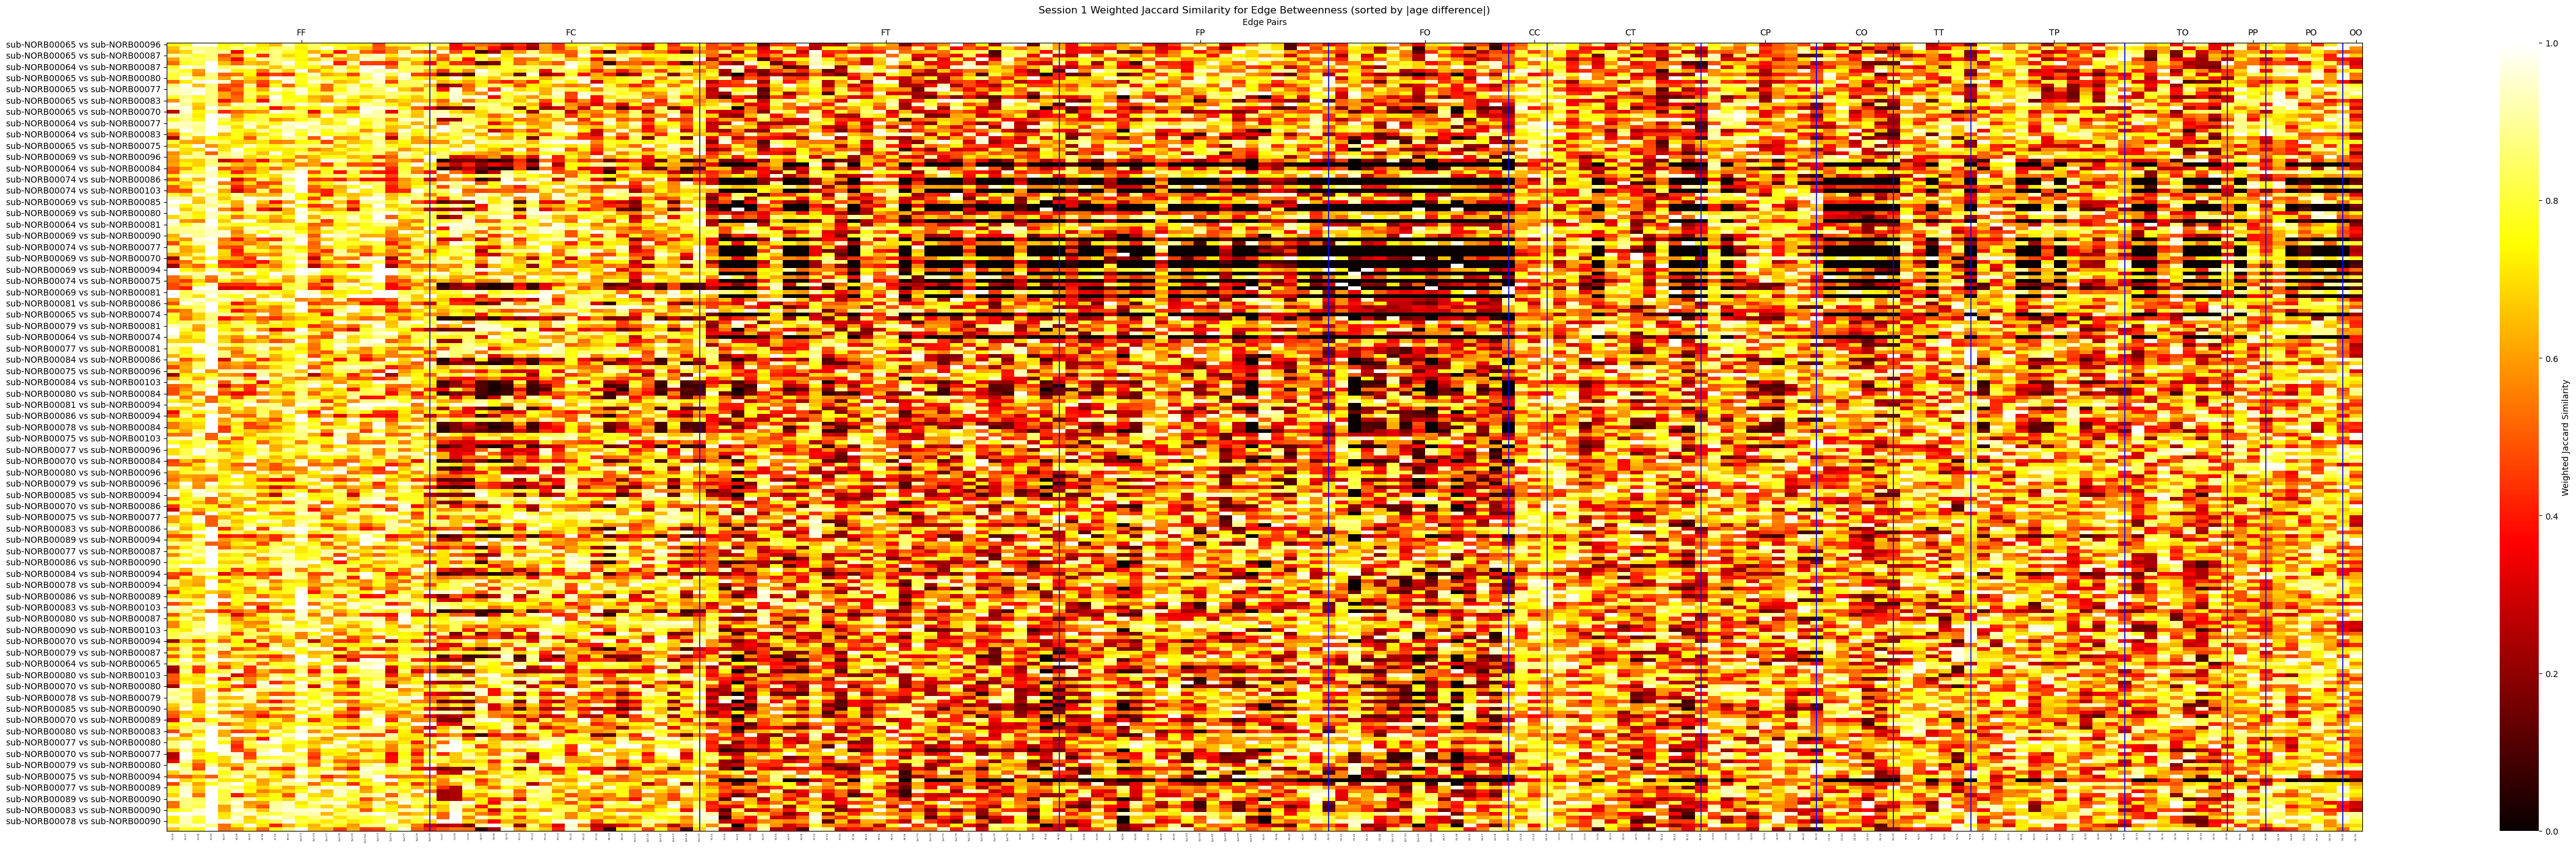

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from itertools import combinations

# Rows: subject pairs (Session 1 only, subjects with multiple sessions), sorted by |age difference|
# Columns: edge pairs grouped by band classes (FF, FC, FT, ..., OO)

age_df = pd.read_csv("age_acq_time_sorted.csv")
age_lookup = dict(zip(age_df["label"], age_df["age_acq_time"]))

# Subjects with multiple sessions based on session-level edge betweenness table
subject_sessions_dict = defaultdict(set)
for ss in session_edge_betweenness_df["subject_session"].unique():
    subject_id, session = ss.split("/")
    subject_sessions_dict[subject_id].add(session)

multi_session_subjects = [subj for subj, sessions in subject_sessions_dict.items() if len(sessions) > 1]
session1_subjects = sorted(multi_session_subjects)

# Keep subjects that have Session 1 in data and age metadata
def ss_session1(subject):
    return f"{subject}/ses-1"

def age_key_session1(subject):
    return f"{subject}_ses-1"

valid_session1_subjects = [
    subj for subj in session1_subjects
    if ss_session1(subj) in session_edge_betweenness_df["subject_session"].values
    and age_key_session1(subj) in age_lookup
]

# Build edge-ordering similar to correlationJaccard heatmap band grouping
band_order = "FCTPO"
order_keys = [a + b for i, a in enumerate(band_order) for b in band_order[i:]]
order_map = {k: i for i, k in enumerate(order_keys)}

# Edge metadata from numeric indices -> channel labels
edge_meta = (
    session_edge_betweenness_df[["node_i", "node_j"]]
    .drop_duplicates()
    .sort_values(["node_i", "node_j"])
    .copy()
)

edge_meta["label_i"] = edge_meta["node_i"].astype(int).map(lambda i: node_labels[i])
edge_meta["label_j"] = edge_meta["node_j"].astype(int).map(lambda j: node_labels[j])
edge_meta["edge_label"] = edge_meta["label_i"] + "-" + edge_meta["label_j"]


def band_key_from_labels(a, b):
    return "".join(sorted((a[0].upper(), b[0].upper()), key=lambda c: band_order.index(c)))

edge_meta["band_key"] = edge_meta.apply(lambda r: band_key_from_labels(r["label_i"], r["label_j"]), axis=1)
edge_meta = edge_meta.sort_values(["band_key", "edge_label"], key=lambda s: s.map(order_map) if s.name == "band_key" else s)
sorted_edge_labels = edge_meta["edge_label"].tolist()

# Normalize pair direction so (A,B) and (B,A) match the same key
jaccard_df = edge_weighted_jaccard_inter_subject_df.copy()
jaccard_df[["ss_min", "ss_max"]] = pd.DataFrame(
    jaccard_df.apply(
        lambda r: sorted([r["subject_session_a"], r["subject_session_b"]]), axis=1
    ).tolist(),
    index=jaccard_df.index,
)

jaccard_lookup = {
    (row.edge_label, row.ss_min, row.ss_max): row.weighted_jaccard_similarity
    for row in jaccard_df.itertuples(index=False)
}

session1_pairs_by_age = []
for sub1, sub2 in combinations(valid_session1_subjects, 2):
    ss1 = ss_session1(sub1)
    ss2 = ss_session1(sub2)
    akey1 = age_key_session1(sub1)
    akey2 = age_key_session1(sub2)
    age_diff = abs(age_lookup[akey1] - age_lookup[akey2])

    ss_min, ss_max = sorted([ss1, ss2])
    values = [jaccard_lookup.get((edge_label, ss_min, ss_max), np.nan) for edge_label in sorted_edge_labels]

    if not np.isnan(values).all():
        session1_pairs_by_age.append(
            {
                "pair_label": f"{sub1} vs {sub2}",
                "age_difference": age_diff,
                "values": values,
            }
        )

session1_pairs_by_age = sorted(session1_pairs_by_age, key=lambda item: item["age_difference"], reverse=True)

session1_edge_jaccard_heatmap_df = pd.DataFrame(
    [item["values"] for item in session1_pairs_by_age],
    index=[item["pair_label"] for item in session1_pairs_by_age],
    columns=sorted_edge_labels,
)

print(f"Session 1 subjects used: {len(valid_session1_subjects)}")
print(f"Heatmap shape: {session1_edge_jaccard_heatmap_df.shape}")
if session1_pairs_by_age:
    print(f"Largest age difference: {session1_pairs_by_age[0]['age_difference']:.4f}")
    print(f"Smallest age difference: {session1_pairs_by_age[-1]['age_difference']:.4f}")

fig_width = max(42, 0.28 * len(sorted_edge_labels))
plt.figure(figsize=(fig_width, 14))
ax = sns.heatmap(
    session1_edge_jaccard_heatmap_df,
    cmap="hot",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Weighted Jaccard Similarity"},
)
ax.set_xticks(np.arange(len(sorted_edge_labels)) + 0.5)
ax.set_xticklabels(sorted_edge_labels, rotation=90, fontsize=3)
ax.tick_params(axis="x", length=0, pad=1)

# Band-group labels and separators on top axis
col_band_keys = edge_meta.set_index("edge_label").loc[sorted_edge_labels, "band_key"].tolist()
unique_band_keys = [k for k in order_keys if k in col_band_keys]

group_positions = []
group_labels = []
group_boundaries = []
for key in unique_band_keys:
    indices = [i for i, k in enumerate(col_band_keys) if k == key]
    if not indices:
        continue
    group_positions.append((indices[0] + indices[-1]) / 2.0 + 0.5)
    group_labels.append(key)
    group_boundaries.append(indices[-1] + 0.5)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(group_positions)
ax_top.set_xticklabels(group_labels, fontsize=10, rotation=0)
ax_top.xaxis.set_ticks_position("top")
ax_top.xaxis.set_label_position("top")
ax_top.set_xlabel("Edge Group")

for boundary in group_boundaries[:-1]:
    ax.axvline(x=boundary, color="blue", linewidth=1.2, zorder=3)

plt.title("Session 1 Weighted Jaccard Similarity for Edge Betweenness (sorted by |age difference|)")
plt.xlabel("Edge Pairs")
plt.ylabel("Subject Pairs (sorted by absolute age difference)")
plt.tight_layout()
plt.savefig("weighted_jaccard_edge_betweenness_session1.png", dpi=300, bbox_inches="tight")
plt.show()

# Session 2 edge-betweenness weighted Jaccard heatmap (inter-subject only)

Session 2 subjects used: 21
Heatmap shape: (210, 171)
Largest age difference: 0.3606
Smallest age difference: 0.0000


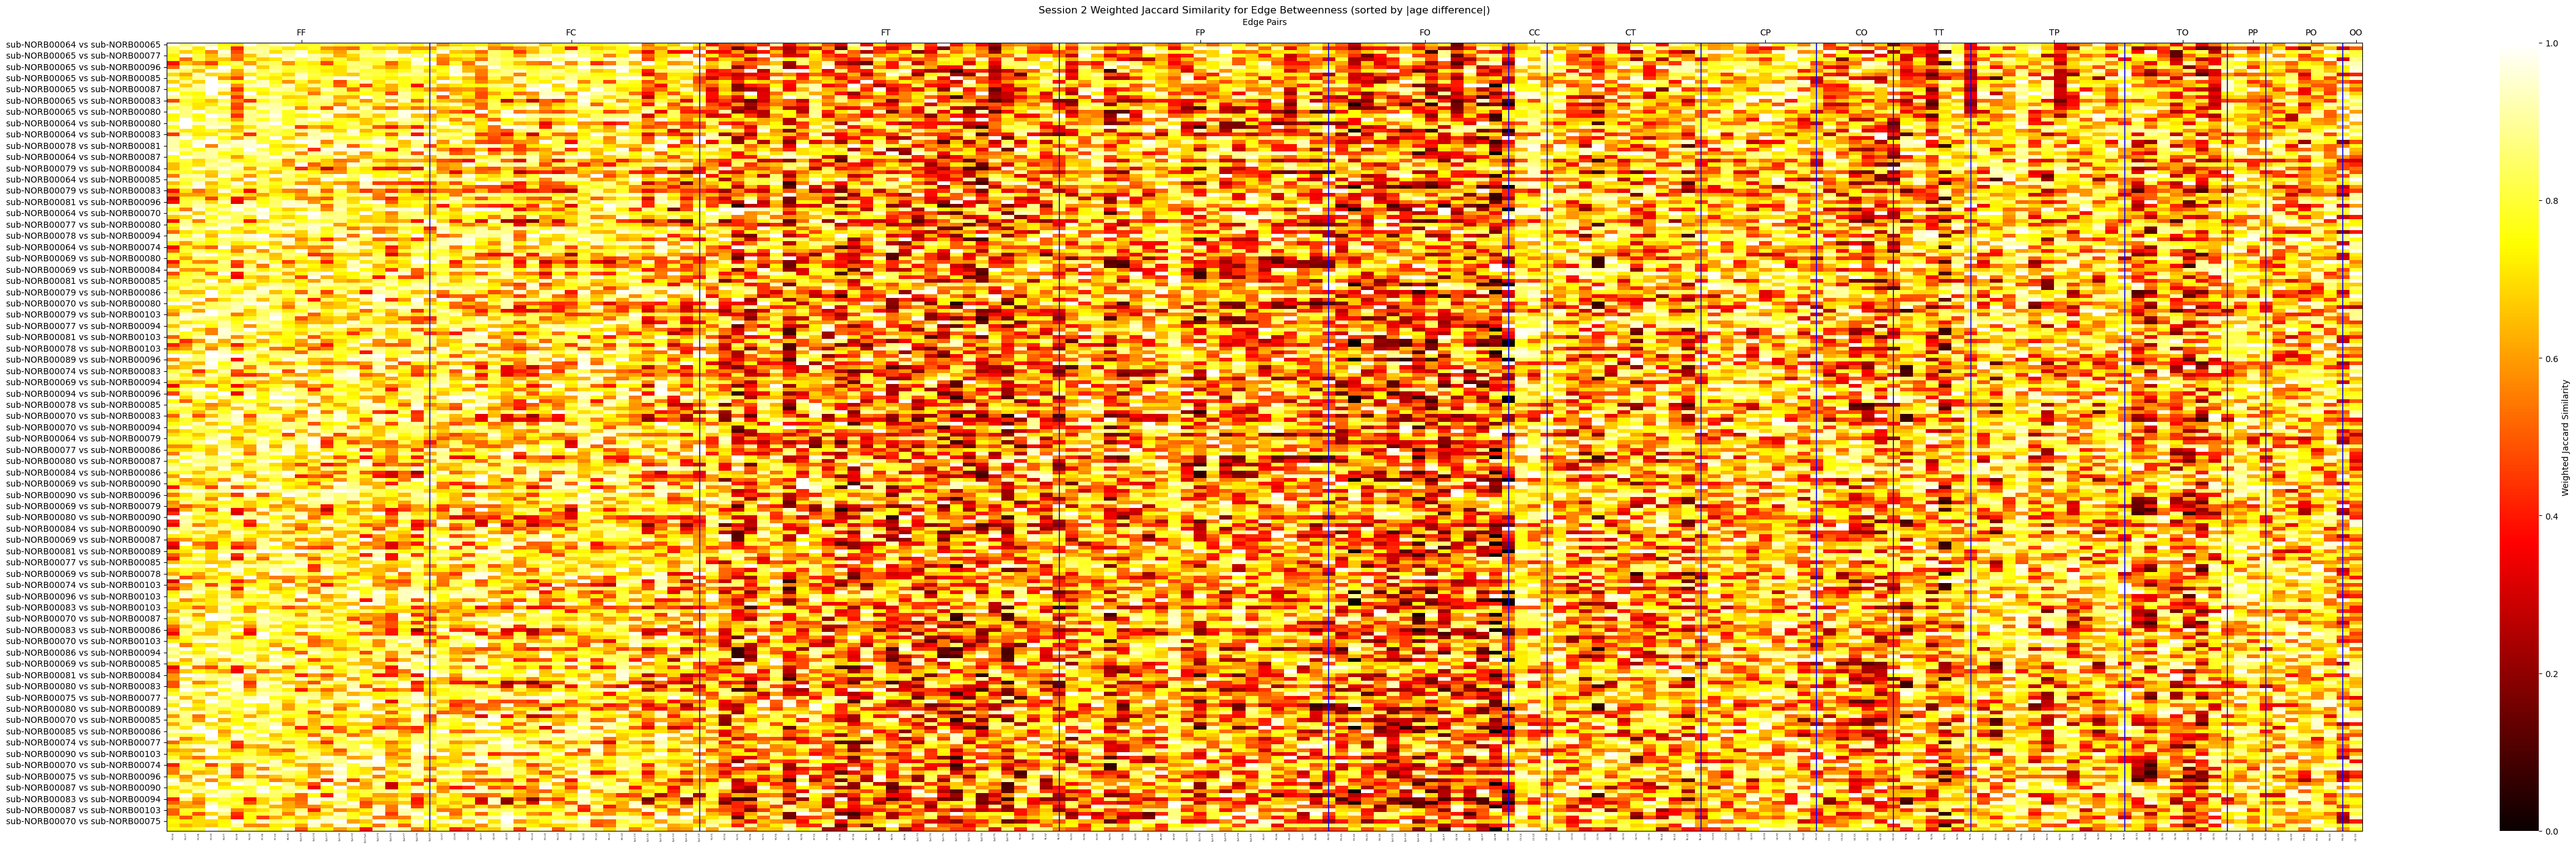

In [7]:
# Same layout as Session 1 heatmap but using ses-2 values

# Keep subjects that have Session 2 in data and age metadata
def ss_session2(subject):
    return f"{subject}/ses-2"

def age_key_session2(subject):
    return f"{subject}_ses-2"

valid_session2_subjects = [
    subj for subj in session1_subjects
    if ss_session2(subj) in session_edge_betweenness_df["subject_session"].values
    and age_key_session2(subj) in age_lookup
]

session2_pairs_by_age = []
for sub1, sub2 in combinations(sorted(valid_session2_subjects), 2):
    ss1 = ss_session2(sub1)
    ss2 = ss_session2(sub2)
    akey1 = age_key_session2(sub1)
    akey2 = age_key_session2(sub2)
    age_diff = abs(age_lookup[akey1] - age_lookup[akey2])

    ss_min, ss_max = sorted([ss1, ss2])
    values = [jaccard_lookup.get((edge_label, ss_min, ss_max), np.nan) for edge_label in sorted_edge_labels]

    if not np.isnan(values).all():
        session2_pairs_by_age.append(
            {
                "pair_label": f"{sub1} vs {sub2}",
                "age_difference": age_diff,
                "values": values,
            }
        )

session2_pairs_by_age = sorted(session2_pairs_by_age, key=lambda item: item["age_difference"], reverse=True)

session2_edge_jaccard_heatmap_df = pd.DataFrame(
    [item["values"] for item in session2_pairs_by_age],
    index=[item["pair_label"] for item in session2_pairs_by_age],
    columns=sorted_edge_labels,
)

print(f"Session 2 subjects used: {len(valid_session2_subjects)}")
print(f"Heatmap shape: {session2_edge_jaccard_heatmap_df.shape}")
if session2_pairs_by_age:
    print(f"Largest age difference: {session2_pairs_by_age[0]['age_difference']:.4f}")
    print(f"Smallest age difference: {session2_pairs_by_age[-1]['age_difference']:.4f}")

fig_width = max(42, 0.28 * len(sorted_edge_labels))
plt.figure(figsize=(fig_width, 14))
ax = sns.heatmap(
    session2_edge_jaccard_heatmap_df,
    cmap="hot",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Weighted Jaccard Similarity"},
)
ax.set_xticks(np.arange(len(sorted_edge_labels)) + 0.5)
ax.set_xticklabels(sorted_edge_labels, rotation=90, fontsize=3)
ax.tick_params(axis="x", length=0, pad=1)

# Band-group labels and separators on top axis (reuse edge_meta/col_band_keys)
col_band_keys = edge_meta.set_index("edge_label").loc[sorted_edge_labels, "band_key"].tolist()
unique_band_keys = [k for k in order_keys if k in col_band_keys]

group_positions = []
group_labels = []
group_boundaries = []
for key in unique_band_keys:
    indices = [i for i, k in enumerate(col_band_keys) if k == key]
    if not indices:
        continue
    group_positions.append((indices[0] + indices[-1]) / 2.0 + 0.5)
    group_labels.append(key)
    group_boundaries.append(indices[-1] + 0.5)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(group_positions)
ax_top.set_xticklabels(group_labels, fontsize=10, rotation=0)
ax_top.xaxis.set_ticks_position("top")
ax_top.xaxis.set_label_position("top")
ax_top.set_xlabel("Edge Group")

for boundary in group_boundaries[:-1]:
    ax.axvline(x=boundary, color="blue", linewidth=1.2, zorder=3)

plt.title("Session 2 Weighted Jaccard Similarity for Edge Betweenness (sorted by |age difference|)")
plt.xlabel("Edge Pairs")
plt.ylabel("Subject Pairs (sorted by absolute age difference)")
plt.tight_layout()
plt.savefig("weighted_jaccard_edge_betweenness_session2.png", dpi=300, bbox_inches="tight")
plt.show()

# Statistics


/tmp/ipykernel_61170/129998942.py:16: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=True)


Using threshold = 0.7; percent columns show percentage of Session 1 values > threshold
Session 1 edge-band summary:


,band_pair,mean,median,std,iqr,percent_above_0.7
0,C-C,0.704820,0.736333,0.189285,0.307631,55.555556
1,C-O,0.507125,0.522774,0.280301,0.426158,28.253968
2,C-P,0.594133,0.608295,0.250561,0.394644,38.571429
3,C-T,0.549528,0.550000,0.260964,0.411791,32.857143
4,F-C,0.627499,0.671429,0.252724,0.369830,45.941043
5,F-F,0.738510,0.758621,0.179669,0.273067,61.111111
6,F-O,0.454007,0.444444,0.302123,0.505091,25.442177
7,F-P,0.519967,0.533333,0.281240,0.437500,31.088435
8,F-T,0.506286,0.500000,0.271540,0.430976,27.840136
9,O-O,0.553189,0.568941,0.244001,0.357051,28.571429


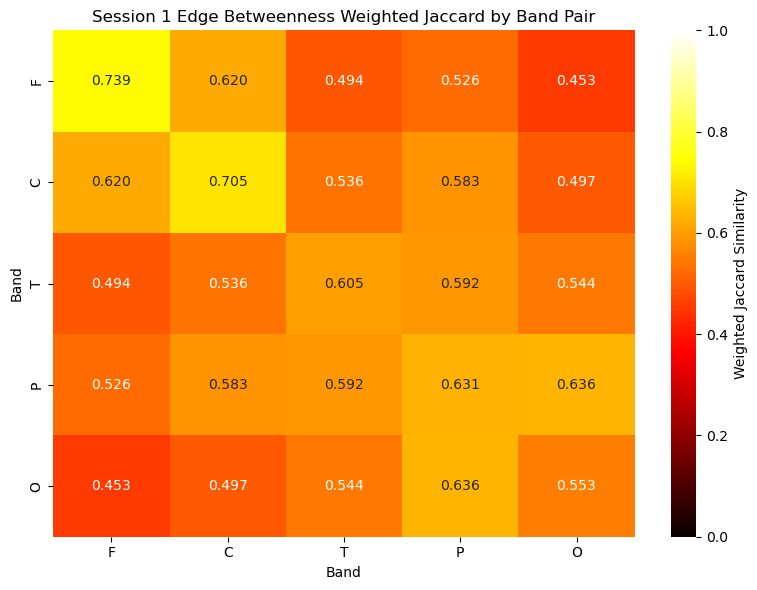

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Threshold for percent-above calculation (changeable)
threshold = 0.7

# Use ONLY Session 1 values that were used in the Session 1 heatmap cell.
if 'session1_edge_jaccard_heatmap_df' not in globals():
    raise NameError('session1_edge_jaccard_heatmap_df is not available. Run the Session 1 heatmap cell first.')

# Convert Session 1 heatmap matrix (subject-pair x edge) into long format and drop NaNs
edge_stats_session1_df = (
    session1_edge_jaccard_heatmap_df
    .stack(dropna=True)
    .reset_index()
    .rename(columns={'level_0': 'subject_pair', 'level_1': 'edge_label', 0: 'weighted_jaccard_similarity'})
)

if edge_stats_session1_df.empty:
    raise ValueError('No Session 1 weighted Jaccard values available for statistics.')

# Derive endpoint bands from edge labels like "F3-PZ" -> F and P
edge_stats_session1_df['label_i'] = edge_stats_session1_df['edge_label'].str.split('-').str[0]
edge_stats_session1_df['label_j'] = edge_stats_session1_df['edge_label'].str.split('-').str[1]
edge_stats_session1_df['band_i'] = edge_stats_session1_df['label_i'].str[0].str.upper()
edge_stats_session1_df['band_j'] = edge_stats_session1_df['label_j'].str[0].str.upper()

band_order = ['F', 'C', 'T', 'P', 'O']
edge_stats_session1_df['band_pair'] = edge_stats_session1_df.apply(
    lambda row: '-'.join(sorted([row['band_i'], row['band_j']], key=lambda band: band_order.index(band))),
    axis=1,
)


def summarize_edge_jaccard(group_cols):
    grouped = edge_stats_session1_df.groupby(group_cols)['weighted_jaccard_similarity']
    summary = grouped.agg(
        mean='mean',
        median='median',
        std='std',
    ).reset_index()
    iqr = grouped.apply(lambda values: values.quantile(0.75) - values.quantile(0.25)).reset_index(name='iqr')
    percent_above = grouped.apply(lambda values: (values > threshold).mean() * 100).reset_index(name=f'percent_above_{threshold}')
    return summary.merge(iqr, on=group_cols, how='left').merge(percent_above, on=group_cols, how='left')


# Edge-level summary by band pair (Session 1 only)
edge_band_summary_df = summarize_edge_jaccard(['band_pair']).sort_values('band_pair')

# Heatmap values: mean weighted Jaccard for each endpoint-band combination (Session 1 only)
heatmap_df = edge_stats_session1_df.pivot_table(
    index='band_i',
    columns='band_j',
    values='weighted_jaccard_similarity',
    aggfunc='mean',
).reindex(index=band_order, columns=band_order)

# Make the matrix symmetric by averaging both directions, so T-P and P-T land on the same value.
symmetric_heatmap = heatmap_df.copy()
for band_a in band_order:
    for band_b in band_order:
        if band_a == band_b:
            continue
        values = [heatmap_df.loc[band_a, band_b], heatmap_df.loc[band_b, band_a]]
        values = [value for value in values if pd.notna(value)]
        if values:
            symmetric_value = float(np.mean(values))
            symmetric_heatmap.loc[band_a, band_b] = symmetric_value
            symmetric_heatmap.loc[band_b, band_a] = symmetric_value

print(f'Using threshold = {threshold}; percent columns show percentage of Session 1 values > threshold')
print('Session 1 edge-band summary:')
display(edge_band_summary_df)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    symmetric_heatmap,
    annot=True,
    fmt='.3f',
    cmap='hot',
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Weighted Jaccard Similarity'},
)
ax.set_xlabel('Band')
ax.set_ylabel('Band')
ax.set_title('Session 1 Edge Betweenness Weighted Jaccard by Band Pair')
plt.tight_layout()
plt.savefig('weighted_jaccard_edge_betweenness_band_heatmap_session1.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
# Count how many Session 1 weighted Jaccard values fall into 0.1-wide bins for each band pair

if 'edge_stats_session1_df' not in globals():
    raise NameError('edge_stats_session1_df is not available. Run the Session 1 Statistics cell first.')

band_bin_edges = np.linspace(0, 1, 11)
band_bin_labels = [f'{band_bin_edges[i]:.1f}-{band_bin_edges[i + 1]:.1f}' for i in range(len(band_bin_edges) - 1)]

band_bin_counts = edge_stats_session1_df.copy()
band_bin_counts['band_pair_display'] = band_bin_counts['band_pair'].str.replace('-', '', regex=False)
band_bin_counts['value_bin'] = pd.cut(
    band_bin_counts['weighted_jaccard_similarity'],
    bins=band_bin_edges,
    labels=band_bin_labels,
    include_lowest=True,
    right=True,
)

band_pair_order = [a + b for i, a in enumerate(band_order) for b in band_order[i:]]
bin_count_table = (
    pd.crosstab(band_bin_counts['band_pair_display'], band_bin_counts['value_bin'])
    .reindex(index=band_pair_order, columns=band_bin_labels, fill_value=0)
)

# Convert raw counts to row-wise percentages for each band_pair (sums to 100%)
bin_percent_table = bin_count_table.div(bin_count_table.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100
bin_percent_table = bin_percent_table.round(2)
print('Percent of Session 1 weighted Jaccard values by band pair and 0.1-wide bin (row-wise %):')
display(bin_percent_table)


Percent of Session 1 weighted Jaccard values by band pair and 0.1-wide bin (row-wise %):


value_bin,0.0-0.1,0.1-0.2,0.2-0.3,0.3-0.4,0.4-0.5,0.5-0.6,0.6-0.7,0.7-0.8,0.8-0.9,0.9-1.0
band_pair_display,,,,,,,,,,
FF,0.00,0.00,1.13,3.20,8.37,11.02,15.26,19.98,19.57,21.47
FC,3.72,4.92,5.08,6.42,9.16,10.95,13.85,16.44,15.03,14.42
FT,7.59,6.65,11.29,12.21,12.91,10.92,10.73,10.78,8.52,8.40
FP,9.32,6.78,7.87,10.84,11.54,11.68,10.98,12.24,9.98,8.78
FO,16.39,8.37,10.10,11.16,9.73,9.49,9.39,9.18,8.50,7.69
CC,0.00,0.16,1.75,4.92,10.48,13.17,14.13,17.62,20.95,16.83
CT,4.44,5.71,9.60,11.23,12.58,13.33,10.32,12.34,10.12,10.32
CP,2.43,5.19,6.46,10.42,11.38,13.02,12.70,13.07,12.70,12.65
CO,10.00,6.27,8.57,11.11,11.35,12.54,12.06,10.79,8.89,8.41


/tmp/ipykernel_61170/211545010.py:17: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=True)


Using threshold = 0.7; percent columns show percentage of Session 2 values > threshold
Session 2 edge-band summary:


,band_pair,mean,median,std,iqr,percent_above_0.7
0,C-C,0.751263,0.777778,0.171780,0.253299,65.079365
1,C-O,0.596764,0.611111,0.229714,0.359532,36.269841
2,C-P,0.685399,0.702914,0.195339,0.309514,50.264550
3,C-T,0.638650,0.661677,0.221754,0.345714,43.730159
4,F-C,0.706947,0.724138,0.189259,0.293129,54.489796
5,F-F,0.763141,0.783784,0.160182,0.234962,67.324263
6,F-O,0.527045,0.500000,0.254259,0.395918,28.129252
7,F-P,0.612185,0.625000,0.225829,0.361505,38.843537
8,F-T,0.572557,0.571429,0.238997,0.384615,33.537415
9,O-O,0.693961,0.720779,0.199214,0.348460,50.952381


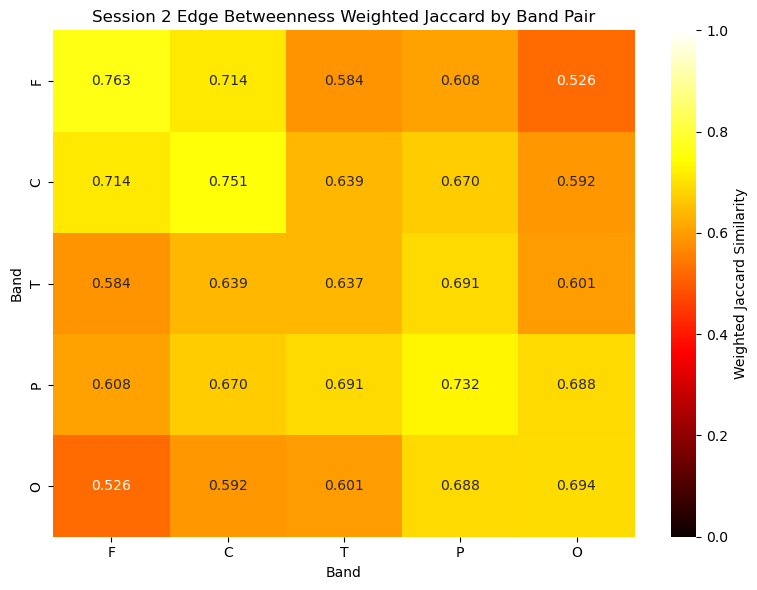

In [10]:
# Session 2-only statistics (same style as Session 1 statistics)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Threshold for percent-above calculation (changeable)
threshold = 0.7

# Use ONLY Session 2 values that were used in the Session 2 heatmap cell.
if 'session2_edge_jaccard_heatmap_df' not in globals():
    raise NameError('session2_edge_jaccard_heatmap_df is not available. Run the Session 2 heatmap cell first.')

# Convert Session 2 heatmap matrix (subject-pair x edge) into long format and drop NaNs
edge_stats_session2_df = (
    session2_edge_jaccard_heatmap_df
    .stack(dropna=True)
    .reset_index()
    .rename(columns={'level_0': 'subject_pair', 'level_1': 'edge_label', 0: 'weighted_jaccard_similarity'})
)

if edge_stats_session2_df.empty:
    raise ValueError('No Session 2 weighted Jaccard values available for statistics.')

# Derive endpoint bands from edge labels like "F3-PZ" -> F and P
edge_stats_session2_df['label_i'] = edge_stats_session2_df['edge_label'].str.split('-').str[0]
edge_stats_session2_df['label_j'] = edge_stats_session2_df['edge_label'].str.split('-').str[1]
edge_stats_session2_df['band_i'] = edge_stats_session2_df['label_i'].str[0].str.upper()
edge_stats_session2_df['band_j'] = edge_stats_session2_df['label_j'].str[0].str.upper()

band_order = ['F', 'C', 'T', 'P', 'O']
edge_stats_session2_df['band_pair'] = edge_stats_session2_df.apply(
    lambda row: '-'.join(sorted([row['band_i'], row['band_j']], key=lambda band: band_order.index(band))),
    axis=1,
)


def summarize_edge_jaccard_session2(group_cols):
    grouped = edge_stats_session2_df.groupby(group_cols)['weighted_jaccard_similarity']
    summary = grouped.agg(
        mean='mean',
        median='median',
        std='std',
    ).reset_index()
    iqr = grouped.apply(lambda values: values.quantile(0.75) - values.quantile(0.25)).reset_index(name='iqr')
    percent_above = grouped.apply(lambda values: (values > threshold).mean() * 100).reset_index(name=f'percent_above_{threshold}')
    return summary.merge(iqr, on=group_cols, how='left').merge(percent_above, on=group_cols, how='left')


# Edge-level summary by band pair (Session 2 only)
edge_band_summary_session2_df = summarize_edge_jaccard_session2(['band_pair']).sort_values('band_pair')

# Heatmap values: mean weighted Jaccard for each endpoint-band combination (Session 2 only)
heatmap_session2_df = edge_stats_session2_df.pivot_table(
    index='band_i',
    columns='band_j',
    values='weighted_jaccard_similarity',
    aggfunc='mean',
).reindex(index=band_order, columns=band_order)

# Make the matrix symmetric by averaging both directions, so T-P and P-T land on the same value.
symmetric_heatmap_session2 = heatmap_session2_df.copy()
for band_a in band_order:
    for band_b in band_order:
        if band_a == band_b:
            continue
        values = [heatmap_session2_df.loc[band_a, band_b], heatmap_session2_df.loc[band_b, band_a]]
        values = [value for value in values if pd.notna(value)]
        if values:
            symmetric_value = float(np.mean(values))
            symmetric_heatmap_session2.loc[band_a, band_b] = symmetric_value
            symmetric_heatmap_session2.loc[band_b, band_a] = symmetric_value

print(f'Using threshold = {threshold}; percent columns show percentage of Session 2 values > threshold')
print('Session 2 edge-band summary:')
display(edge_band_summary_session2_df)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    symmetric_heatmap_session2,
    annot=True,
    fmt='.3f',
    cmap='hot',
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Weighted Jaccard Similarity'},
)
ax.set_xlabel('Band')
ax.set_ylabel('Band')
ax.set_title('Session 2 Edge Betweenness Weighted Jaccard by Band Pair')
plt.tight_layout()
plt.savefig('weighted_jaccard_edge_betweenness_band_heatmap_session2.png', dpi=300, bbox_inches='tight')
plt.show()
